In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df=pd.read_csv('../data/chunked/chunks.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   chunk_id     566 non-null    str  
 1   doc_id       566 non-null    str  
 2   title        566 non-null    str  
 3   topic        566 non-null    str  
 4   url          566 non-null    str  
 5   source_type  566 non-null    str  
 6   source_name  566 non-null    str  
 7   section      566 non-null    str  
 8   chunk_order  566 non-null    int64
 9   last_edited  98 non-null     str  
 10  retrieved    566 non-null    str  
 11  chunk_text   566 non-null    str  
dtypes: int64(1), str(11)
memory usage: 53.2 KB


In [16]:
display(df.head())

,chunk_id,doc_id,title,topic,url,source_type,source_name,section,chunk_order,last_edited,retrieved,chunk_text
0,gov_001_001,gov_001,Optional Practical Training (OPT) for F-1 Stud...,opt,https://www.uscis.gov/working-in-the-united-st...,gov,uscis,Optional Practical Training (OPT) for F-1 Stud...,1,11/25/2024,4/19/2026,Optional practical training (OPT) is temporary...
1,gov_001_002,gov_001,Optional Practical Training (OPT) for F-1 Stud...,opt,https://www.uscis.gov/working-in-the-united-st...,gov,uscis,Optional Practical Training (OPT) for F-1 Stud...,2,11/25/2024,4/19/2026,All OPT must be directly related to your major...
2,gov_001_003,gov_001,Optional Practical Training (OPT) for F-1 Stud...,opt,https://www.uscis.gov/working-in-the-united-st...,gov,uscis,Optional Practical Training (OPT) for F-1 Stud...,3,11/25/2024,4/19/2026,If you have earned a degree in certain Science...
3,gov_001_004,gov_001,Optional Practical Training (OPT) for F-1 Stud...,opt,https://www.uscis.gov/working-in-the-united-st...,gov,uscis,Optional Practical Training (OPT) for F-1 Stud...,4,11/25/2024,4/19/2026,"Generally, you must:\n\n- Request that your de..."
4,gov_001_005,gov_001,Optional Practical Training (OPT) for F-1 Stud...,opt,https://www.uscis.gov/working-in-the-united-st...,gov,uscis,Optional Practical Training (OPT) for F-1 Stud...,5,11/25/2024,4/19/2026,If you are applying based on a… \nSTEM degree ...


In [17]:
# =====================================================
# 1. Basic Data Quality Check
# =====================================================

print("Missing values:")
display(df.isna().sum())

print("\nDuplicate chunk_id count:")
print(df["chunk_id"].duplicated().sum())

print("\nDuplicate chunk_text count:")
print(df["chunk_text"].duplicated().sum())

# for the duplicated text chunks, it appears to be text snippet resued across related topics.

Missing values:


chunk_id         0
doc_id           0
title            0
topic            0
url              0
source_type      0
source_name      0
section          0
chunk_order      0
last_edited    468
retrieved        0
chunk_text       0
dtype: int64


Duplicate chunk_id count:
0

Duplicate chunk_text count:
64


In [18]:
# =====================================================
# 2. Add Derived Metrics
# =====================================================

df["word_count"] = df["chunk_text"].fillna("").apply(
    lambda x: len(str(x).split())
)

df["char_count"] = df["chunk_text"].fillna("").apply(
    lambda x: len(str(x))
)

print(df[["word_count", "char_count"]].describe())

       word_count   char_count
count  566.000000   566.000000
mean   160.796820  1099.839223
std    163.215898  1176.521318
min      3.000000    17.000000
25%     36.000000   243.250000
50%     86.500000   580.000000
75%    241.750000  1580.500000
max    500.000000  8564.000000


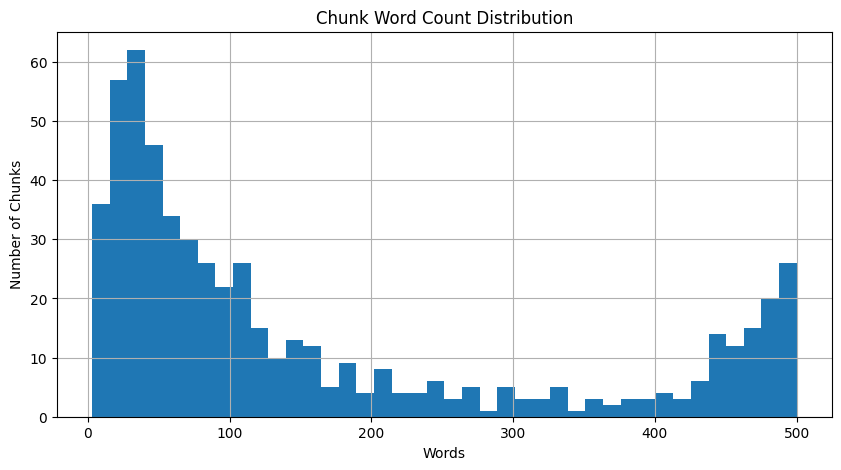

In [19]:
# =====================================================
# 3. Chunk Size Distribution
# =====================================================

plt.figure(figsize=(10,5))
df["word_count"].hist(bins=40)
plt.title("Chunk Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Number of Chunks")
plt.show()

In [20]:
# =====================================================
# 4. Chunk Size Categories
# =====================================================

def size_bucket(n):
    if n < 20:
        return "tiny (<20)"
    elif n < 80:
        return "small (20-79)"
    elif n < 250:
        return "medium (80-249)"
    elif n < 500:
        return "large (250-499)"
    else:
        return "maxed (500+)"

df["size_bucket"] = df["word_count"].apply(size_bucket)

print("Chunk Size Categories:")
display(df["size_bucket"].value_counts())

Chunk Size Categories:


size_bucket
small (20-79)      218
medium (80-249)    158
large (250-499)    133
tiny (<20)          51
maxed (500+)         6
Name: count, dtype: int64

In [21]:

# =====================================================
# 5. Tiny Chunks Audit
# =====================================================

tiny = df[df["word_count"] < 20]

print("Tiny chunks count:", len(tiny))

display(
    tiny[
        ["chunk_id", "source_name", "section", "word_count", "chunk_text"]
    ].head(30)
)

tiny.to_csv('../data/chunked/small_chunks.csv')

Tiny chunks count: 51


,chunk_id,source_name,section,word_count,chunk_text
18,gov_003_003,uscis,Students and Employment > M-1 Student Visa,18,The M-1 visa (Vocational Student) category inc...
86,gov_010_007,uscis,How Do I Request Premium Processing? > How do ...,17,Check the Edition Date section of our [Form I-...
115,gov_013_004,dhs,Contact Us,18,SEVP Response Center\n\n703-603-3400\n\nMonday...
145,uni_001_020,columbia,Submit Your OPT I-765 Application online throu...,7,- Choose ONLY “(c)(3)(A) Student Pre-Completio...
146,uni_001_021,columbia,Submit Your OPT I-765 Application online throu...,8,- Choose the option “Initial permission for em...
148,uni_001_023,columbia,Submit Your OPT I-765 Application online throu...,13,"- Scroll down to “F1 - F1 - Student, Academic ..."
161,uni_001_036,columbia,USCIS Processing Time and EAD Delivery FAQs > ...,19,"Generally, USCIS will adjust the start date on..."
166,uni_002_001,columbia,Travel Signatures and I-20/DS-2019 Reprints (F...,3,**On This Page:**
175,uni_002_010,columbia,Travel Signatures and I-20/DS-2019 Reprints (F...,12,Access your most recent [I-94 Arrival Record](...
186,uni_003_009,columbia,Traveling Outside the U.S. > J-2 Student Depen...,7,Watch our short international travel overview ...


In [22]:
# =====================================================
# 6. Largest Chunks Audit
# =====================================================

largest = df.sort_values("word_count", ascending=False)

display(
    largest[
        ["chunk_id", "source_name", "section", "word_count"]
    ].head(20)
)

,chunk_id,source_name,section,word_count
564,uni_036_001,njit,Replacement EAD,500
62,gov_006_012,uscis,H-1B Specialty Occupations > Changing Employer...,500
519,uni_026_003,njit,Reestablishing F-1 Status > You may gain F-1 S...,500
9,gov_002_003,uscis,"I-765, Application for Employment Authorizatio...",500
523,uni_028_002,njit,Optional Practical Training,500
518,uni_026_002,njit,Reestablishing F-1 Status > You may gain F-1 S...,500
31,gov_005_003,uscis,Chapter 5 - Practical Training,499
480,uni_021_005,berkeley,The H-1B > Basics & Eligibility,499
450,uni_016_007,berkeley,What is Curricular Practical Training (CPT)? >...,498
507,uni_023_001,njit,Visa Information & Application Process,497


In [23]:
# =====================================================
# 7. Source-Level Analysis
# =====================================================

source_summary = df.groupby("source_name").agg(
    total_chunks=("chunk_id", "count"),
    avg_words=("word_count", "mean"),
    median_words=("word_count", "median"),
    tiny_chunks=("word_count", lambda x: (x < 20).sum())
).reset_index()

display(source_summary)

,source_name,total_chunks,avg_words,median_words,tiny_chunks
0,berkeley,75,249.106667,190.0,0
1,columbia,306,71.790850,48.0,47
2,dhs,32,150.906250,97.0,1
3,ice,10,82.500000,66.0,0
4,njit,59,347.796610,419.0,1
5,uscis,84,287.928571,295.5,2


In [24]:
# =====================================================
# 8. Topic-Level Analysis
# =====================================================

topic_summary = df.groupby("topic").agg(
    total_chunks=("chunk_id", "count"),
    avg_words=("word_count", "mean")
).reset_index().sort_values("total_chunks", ascending=False)

display(topic_summary)

,topic,total_chunks,avg_words
18,opt extension,59,60.118644
17,opt,56,127.821429
20,post opt,49,76.755102
10,h1b,43,164.930233
21,pre opt,40,56.875000
4,cpt,39,209.923077
28,traveling,28,153.535714
25,stem opt,27,339.629630
19,opt reporting,23,71.260870
0,Practical Training,22,430.954545


In [25]:
# =====================================================
# 9. Missing Freshness Metadata
# =====================================================

print("Missing last_edited:", df["last_edited"].isna().sum())
print("Missing retrieved:", df["retrieved"].isna().sum())


# =====================================================
# 10. Random Manual Review
# =====================================================

sample = df.sample(10, random_state=42)

display(
    sample[
        ["chunk_id", "section", "word_count", "chunk_text"]
    ]
)

Missing last_edited: 468
Missing retrieved: 0


,chunk_id,section,word_count,chunk_text
539,uni_030_001,24-Month STEM OPT Extension,491,A 24-month STEM OPT Extension is available for...
524,uni_028_003,Optional Practical Training,476,- The program end date is the last day of fina...
234,uni_006_021,FAQs (Frequently Asked Questions) > What if my...,81,You can count only ONE online class toward you...
525,uni_028_004,Optional Practical Training,392,- Students should carefully consider the date ...
489,uni_022_005,4. Am I eligible for H-1B status since I have ...,27,Not necessarily. The job itself must require a...
318,uni_009_034,USCIS Processing Time and EAD Delivery FAQs > ...,38,"Unfortunately, it is not possible to know exac..."
247,uni_008_003,Before You Apply > When you can use OPT,30,You may use OPT during and/or after your degre...
499,uni_022_015,14. How should I explain H-1B status to a pros...,83,It is important for an employer to understand ...
423,uni_013_010,Cap-Gap OPT Extension > Travel During Cap-Gap ...,16,It will nullify the change of status and make ...
222,uni_006_009,Before You Apply > Effect of CPT on OPT duration,57,Time authorized for CPT is not deducted from t...


In [26]:
# =====================================================
# 11. Executive Summary
# =====================================================

print("SUMMARY")
print("-------")
print("Total chunks:", len(df))
print("Average words:", round(df["word_count"].mean(), 1))
print("Median words:", round(df["word_count"].median(), 1))
print("Tiny chunks (<20):", (df["word_count"] < 20).sum())
print("Large chunks (250+):", (df["word_count"] >= 250).sum())
print("Max chunk words:", df["word_count"].max())

SUMMARY
-------
Total chunks: 566
Average words: 160.8
Median words: 86.5
Tiny chunks (<20): 51
Large chunks (250+): 139
Max chunk words: 500
